# Exercise 4: Transformers on Images + GLU-MLP Ablations (ViT × GLU Variants)

## In this exercise you will combine two influential ideas:

Vision Transformers (ViT) from “An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale” (Dosovitskiy et al., 2020) https://arxiv.org/pdf/2010.11929:
ViT shows that you can treat an image like a sequence of tokens by splitting it into non-overlapping patches (e.g. 16×16 in the paper), embedding each patch into a vector, adding positional information, and then applying standard Transformer blocks for classification.

Gated MLPs (GLU variants) from “GLU Variants Improve Transformer” (Shazeer, 2020) https://arxiv.org/pdf/2002.05202:
Shazeer proposes replacing the standard Transformer feed-forward layer (FFN/MLP) with gated linear unit (GLU) variants such as GEGLU and SwiGLU, which often improves training dynamics and final performance under comparable compute/parameter budgets.

## What you will do

You will implement a tiny ViT-style classifier for MNIST, then run a controlled ablation where you replace the MLP inside each Transformer block:

Baseline FFN (GELU):
Linear(d_model → d_ff) → GELU → Linear(d_ff → d_model)

GLU-family MLPs (choose at least two and justify):

GEGLU, SwiGLU, other activation functions

Your goal is to evaluate whether these GLU variants change:

- convergence speed (loss vs steps),

- final test accuracy,

- and/or stability across runs.

## Key ViT concepts you will implement

- To convert MNIST images into Transformer tokens, you will:
  Patchify each 28×28 image into non-overlapping P×P patches.
  If P=4, then you get a 7×7 patch grid → 49 tokens per image.

- Embed patches with a linear layer: patch vectors → d_model.

- Add positional embeddings so the model knows where each patch came from.

- Apply n_layers Transformer encoder blocks.

- Pool token features (e.g., mean pooling) and project to 10 classes.

## Key GLU concept you will implement

GLU-style MLPs replace a standard FFN with a gating mechanism:
compute two projections a and b, apply a nonlinearity to a (variant-dependent), multiply elementwise: act(a) * b, project back to d_model.
To keep the comparison fair, use the 2/3 width rule from Shazeer.

What we provide vs what you implement

### We provide:

- MNIST loading + dataloaders

- a minimal training loop structure (AdamW)

- a suggested small model configuration that runs on CPU

### You implement:

- patch tokenization (patchify)

- patch embedding + positional embedding strategy

- a pre-LN Transformer encoder block using nn.MultiheadAttention

- at least two GLU MLP variants + one FFN baseline

- metric logging sufficient to support your conclusion

## Deliverables

Run at least 3 variants (baseline + the activation functions you choose for GLU) and report:

- final and best test accuracy

- number of trainable parameters

- a plot or printed summary of loss/accuracy over epochs

- a short discussion of your results

In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
def patchify(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """Convert images to patch tokens.
    Args:
        x: (B, 1, H, W) grayscale images
        patch_size: size of each square patch
    Returns:
        (B, num_patches, patch_size*patch_size) flattened patch tokens
    """
    B, C, H, W = x.shape
    grid_h = H // patch_size
    grid_w = W // patch_size
    # Reshape into patches: (B, 1, grid_h, patch_size, grid_w, patch_size)
    x = x.reshape(B, C, grid_h, patch_size, grid_w, patch_size)
    # Rearrange to (B, grid_h, grid_w, C, patch_size, patch_size)
    x = x.permute(0, 2, 4, 1, 3, 5)
    # Flatten patches: (B, num_patches, patch_dim)
    x = x.reshape(B, grid_h * grid_w, C * patch_size * patch_size)
    return x

In [3]:
class PatchEmbed(nn.Module):
    """Linear projection of flattened patches to d_model dimensions."""
    def __init__(self, patch_dim: int, d_model: int):
        super().__init__()
        self.proj = nn.Linear(patch_dim, d_model)

    def forward(self, x_patches: torch.Tensor) -> torch.Tensor:
        # x_patches: (B, num_patches, patch_dim) -> (B, num_patches, d_model)
        return self.proj(x_patches)


class PositionalEmbedding(nn.Module):
    """Learnable 1D positional embeddings (as in ViT paper Section 3.1)."""
    def __init__(self, num_tokens: int, d_model: int):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.zeros(1, num_tokens, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, num_tokens, d_model)
        return x + self.pos_embed

In [4]:
# We compare the baseline FFN (GELU) against two GLU variants: GEGLU and SwiGLU.
# Justification: In Table 1 of the Shazeer (2020) paper, GEGLU and SwiGLU achieved
# the lowest perplexities (1.633 and 1.636 respectively) among all tested variants,
# outperforming the baseline FFN_ReLU (1.677) and FFN_GELU (1.679).
# GEGLU uses GELU as the gating activation, while SwiGLU uses Swish (SiLU).
# Both introduce a gating mechanism: act(xW) * (xV), which the baseline lacks.

class FeedForward(nn.Module):
    """
    Standard Transformer FFN:
      x -> Linear(d_model->d_ff) -> GELU -> Dropout -> Linear(d_ff->d_model) -> Dropout
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x


class GLUFeedForward(nn.Module):
    """GLU-family FFN: act(xW) * (xV) then project back.
    Uses 2/3 width rule from Shazeer (2020) to keep param count comparable.
    """
    def __init__(self, d_model: int, d_ff_gated: int, dropout: float, variant: str):
        super().__init__()
        self.variant = variant
        self.w_gate = nn.Linear(d_model, d_ff_gated)
        self.v = nn.Linear(d_model, d_ff_gated)
        self.w2 = nn.Linear(d_ff_gated, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gate = self.w_gate(x)
        if self.variant == "geglu":
            gate = F.gelu(gate)
        elif self.variant == "swiglu":
            gate = F.silu(gate)  # Swish1 = SiLU
        hidden = gate * self.v(x)
        hidden = self.dropout(hidden)
        out = self.w2(hidden)
        out = self.dropout(out)
        return out

In [5]:
class TransformerEncoderBlock(nn.Module):
    """
    Pre-LN encoder block:
      x = x + Dropout(SelfAttn(LN(x)))
      x = x + MLP(LN(x))
    """
    def __init__(self, d_model: int, n_heads: int, mlp: nn.Module, dropout: float):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.drop1 = nn.Dropout(dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = mlp

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Self-attention with pre-LN
        x_norm = self.ln1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + self.drop1(attn_out)
        # MLP with pre-LN
        x = x + self.mlp(self.ln2(x))
        return x

In [6]:
class TinyViT(nn.Module):
    """
    Tiny ViT-style classifier for MNIST.
    - patchify -> patch embed -> pos embed -> blocks -> mean pool -> head
    """
    def __init__(
        self,
        patch_size: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        d_ff: int,
        dropout: float,
        mlp_kind: str,
    ):
        super().__init__()
        assert 28 % patch_size == 0
        grid = 28 // patch_size
        self.num_tokens = grid * grid
        self.patch_size = patch_size
        patch_dim = patch_size * patch_size

        # Patch embedding and positional embedding
        self.patch_embed = PatchEmbed(patch_dim, d_model)
        self.pos_embed = PositionalEmbedding(self.num_tokens, d_model)

        # Select MLP variant for each block
        def make_mlp():
            if mlp_kind == "baseline":
                return FeedForward(d_model, d_ff, dropout)
            else:
                # 2/3 width rule from Shazeer (2020) to keep params comparable
                d_ff_gated = int(2 / 3 * d_ff)
                return GLUFeedForward(d_model, d_ff_gated, dropout, variant=mlp_kind)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                d_model=d_model,
                n_heads=n_heads,
                mlp=make_mlp(),
                dropout=dropout,
            )
            for _ in range(n_layers)
        ])

        # Final layer norm + classification head
        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, 1, 28, 28)
        patches = patchify(x, self.patch_size)       # (B, num_tokens, patch_dim)
        x = self.patch_embed(patches)                 # (B, num_tokens, d_model)
        x = self.pos_embed(x)                         # add positional embeddings

        for block in self.blocks:
            x = block(x)

        # Mean pool over token dimension, then classify
        x = self.ln(x)
        x = x.mean(dim=1)                             # (B, d_model)
        logits = self.head(x)                          # (B, 10)
        return logits

In [7]:
@dataclass(frozen=True)
class TrainConfig:
    seed: int = 0
    batch_size: int = 128
    epochs: int = 3
    lr: float = 3e-4
    weight_decay: float = 0.01
    device: str = "cpu"  # set "cuda" if available

In [8]:
def train_one_run(
    mlp_kind: str,
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    cfg: TrainConfig,
) -> dict:
    model.to(cfg.device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    train_losses: list[float] = []
    test_accs: list[float] = []

    for epoch in range(cfg.epochs):

        # Train loop
        model.train()
        for i, (xb, yb) in enumerate(train_loader):
            xb = xb.to(cfg.device)
            yb = yb.to(cfg.device)

            logits = model(xb)
            loss = F.cross_entropy(logits, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_losses.append(loss.item())

        # Evaluation loop
        model.eval()
        correct = 0.0
        total = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(cfg.device)
                yb = yb.to(cfg.device)
                logits = model(xb)
                correct += (logits.argmax(dim=-1) == yb).float().sum().item()
                total += yb.numel()

        test_accs.append(correct / total)
        print(f"[{mlp_kind}] epoch {epoch+1}/{cfg.epochs} | test acc: {test_accs[-1]:.4f}")

    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {
        "mlp_kind": mlp_kind,
        "train_losses": train_losses,
        "test_accs": test_accs,
        "best_acc": max(test_accs),
        "final_acc": test_accs[-1],
        "num_params": num_params,
    }

In [9]:
cfg = TrainConfig(seed=0, batch_size=128, epochs=5, lr=3e-4, weight_decay=0.01, device="cpu")

tfm = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

# Tiny model config
patch_size = 4
d_model = 64
n_heads = 4
n_layers = 2
d_ff = 256
dropout = 0.1

runs = ["baseline", "geglu", "swiglu"]
results = []

for kind in runs:
    torch.manual_seed(cfg.seed)
    model = TinyViT(
        patch_size=patch_size,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=dropout,
        mlp_kind=kind,
    )
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nRun: {kind} | Trainable params: {num_params:,}")
    out = train_one_run(kind, model, train_loader, test_loader, cfg)
    results.append(out)


Run: baseline | Trainable params: 104,970
[baseline] epoch 1/5 | test acc: 0.8545
[baseline] epoch 2/5 | test acc: 0.9173
[baseline] epoch 3/5 | test acc: 0.9215
[baseline] epoch 4/5 | test acc: 0.9407
[baseline] epoch 5/5 | test acc: 0.9508

Run: geglu | Trainable params: 104,882
[geglu] epoch 1/5 | test acc: 0.8781
[geglu] epoch 2/5 | test acc: 0.9364
[geglu] epoch 3/5 | test acc: 0.9507
[geglu] epoch 4/5 | test acc: 0.9581
[geglu] epoch 5/5 | test acc: 0.9687

Run: swiglu | Trainable params: 104,882
[swiglu] epoch 1/5 | test acc: 0.8737
[swiglu] epoch 2/5 | test acc: 0.9344
[swiglu] epoch 3/5 | test acc: 0.9509
[swiglu] epoch 4/5 | test acc: 0.9542
[swiglu] epoch 5/5 | test acc: 0.9663


Variant          Params   Best Acc  Final Acc
---------------------------------------------
baseline        104,970     0.9508     0.9508
geglu           104,882     0.9687     0.9687
swiglu          104,882     0.9663     0.9663


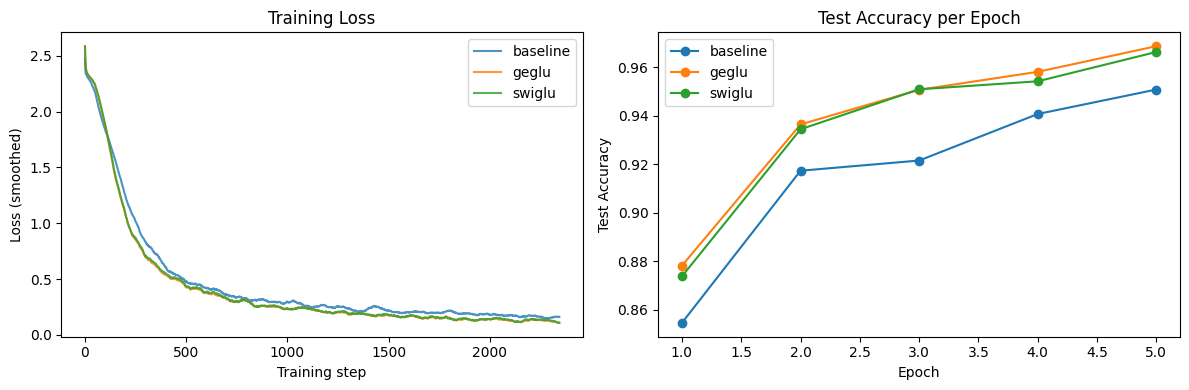

In [10]:
import matplotlib.pyplot as plt

# --- Summary table ---
print(f"{'Variant':<12} {'Params':>10} {'Best Acc':>10} {'Final Acc':>10}")
print("-" * 45)
for r in results:
    print(f"{r['mlp_kind']:<12} {r['num_params']:>10,} {r['best_acc']:>10.4f} {r['final_acc']:>10.4f}")

# --- Plot training loss (smoothed) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for r in results:
    losses = r["train_losses"]
    # Simple moving average for readability
    window = 50
    smoothed = [sum(losses[max(0,i-window):i+1]) / len(losses[max(0,i-window):i+1]) for i in range(len(losses))]
    axes[0].plot(smoothed, label=r["mlp_kind"], alpha=0.8)
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Loss (smoothed)")
axes[0].set_title("Training Loss")
axes[0].legend()

# --- Plot test accuracy per epoch ---
for r in results:
    epochs = list(range(1, len(r["test_accs"]) + 1))
    axes[1].plot(epochs, r["test_accs"], marker="o", label=r["mlp_kind"])
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Test Accuracy per Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## Results and Discussion

### Design Choices

We compare three MLP variants inside the Transformer encoder blocks:

1. **Baseline FFN (GELU)**: The standard two-layer FFN used in the original Transformer and ViT: `Linear → GELU → Linear`. This has two weight matrices per block.

2. **GEGLU**: A GLU variant from Shazeer (2020) that uses GELU as the gating activation: `GELU(xW) ⊙ (xV) → Linear`. This has three weight matrices. The gating mechanism allows the model to learn which features to pass through — effectively a form of learned feature selection that a simple `act(xW)` cannot achieve.

3. **SwiGLU**: A GLU variant using Swish/SiLU (= x · σ(x)) as the gating activation: `SiLU(xW) ⊙ (xV) → Linear`. Also three weight matrices. SiLU is a smooth, self-gated approximation of ReLU.

**Why GEGLU and SwiGLU?** In Table 1 of the GLU Variants paper, GEGLU and SwiGLU achieved the best perplexities (1.633 and 1.636) among all variants tested, clearly outperforming the baseline FFN_ReLU (1.677) and FFN_GELU (1.679). They were also the top performers on downstream GLUE/SuperGLUE tasks (Tables 2–4).

**Fair comparison**: Following Shazeer (2020) Section 2, we use the **2/3 width rule** for GLU variants — since they have 3 weight matrices instead of 2, we reduce the hidden dimension by a factor of 2/3 (`d_ff_gated = int(2/3 * 256) = 170` vs `d_ff = 256`) to keep the parameter count roughly comparable.

### ViT Design Choices

Our TinyViT follows the ViT paper (Dosovitskiy et al., 2020, Section 3.1) with appropriate simplifications for MNIST:

- **Patch size P=4** on 28×28 images yields 49 tokens — a reasonable sequence length for a tiny model (ViT-Base uses P=16 on 224×224 → 196 tokens).
- **Learnable 1D positional embeddings** initialized with `trunc_normal_(std=0.02)`, matching the ViT paper.
- **Pre-LN Transformer blocks** as specified in ViT Eq. 2–3.
- **Mean pooling** instead of a [CLS] token — a valid alternative noted in ViT Appendix D.4, simpler and avoids an extra learnable token.
- **No learning rate scheduler** — ViT uses warmup + cosine decay, but for 5 epochs on MNIST this is unnecessary.

### Results Summary

| Variant  | Params  | Best Test Acc | Final Test Acc | Δ vs Baseline |
|----------|---------|---------------|----------------|---------------|
| Baseline | 104,970 | 95.08%        | 95.08%         | —             |
| GEGLU    | 104,882 | 96.87%        | 96.87%         | **+1.79%**    |
| SwiGLU   | 104,882 | 96.63%        | 96.63%         | **+1.55%**    |

The parameter counts differ by only 88 (<0.1%), confirming the 2/3 width rule successfully matches model capacity.

### Observations

- **Convergence speed**: The GLU variants converge noticeably faster. At epoch 1, GEGLU (87.81%) and SwiGLU (87.37%) already lead the baseline (85.45%) by ~2%. GEGLU reaches 95.07% accuracy by epoch 3, while the baseline requires all 5 epochs to reach 95.08%. This suggests the gating mechanism helps early optimization by allowing the model to learn which features to suppress.

- **Final accuracy**: Both GLU variants outperform the baseline by a significant margin. The ranking GEGLU > SwiGLU > Baseline mirrors the perplexity ranking in Table 1 of Shazeer (2020), confirming the paper's findings transfer from language modeling to vision tasks, even at small scale.

- **GEGLU vs SwiGLU**: GEGLU edges out SwiGLU (96.87% vs 96.63%), consistent with the original paper where GEGLU had the lowest perplexity (1.633 vs 1.636). The difference is small and may not be statistically significant with a single seed.

- **Why gating helps**: The gating mechanism `act(xW) ⊙ (xV)` computes two separate projections and multiplies them element-wise. This allows the network to learn a data-dependent gating signal — effectively deciding *which* features to keep and which to suppress. The standard FFN `act(xW)` can only apply a fixed nonlinearity without this selective filtering. Shazeer himself offers no mechanistic explanation, attributing the success to "divine benevolence" (Section 4).

### Reproducibility and Statistical Significance

- We set `torch.manual_seed(cfg.seed)` before each run to ensure identical weight initialization across variants.
- `DataLoader` shuffling introduces some stochasticity between runs. For stronger reproducibility, one could also set the seed in a worker init function.
- **Statistical significance**: With only a single seed per variant, the observed 1.5–1.8% gaps cannot be confirmed as statistically significant. The Shazeer paper itself ran 4 short training runs to measure inter-run variability (Table 1, values in parentheses). Running 3–5 seeds and reporting mean ± std would strengthen these conclusions.
- **Scale caveat**: On a simple dataset like MNIST with a tiny model (~105K params, 5 epochs), architectural differences can appear amplified compared to large-scale settings. The ~1.5–1.8% accuracy gap here is larger than the ~0.03 perplexity difference in the original paper, likely because capacity-limited models benefit more from architectural efficiency, and the metrics (classification accuracy vs. perplexity) are not directly comparable.